Introduction

This analysis examines global meat consumption patterns for the year 2022, focusing specifically on identifying the top 20 countries with the highest daily per-capita intake. Using data from the daily-meat-consumption-per-person dataset, the study evaluates how much meat, measured in grams per person per day, was consumed across different nations during that year. By filtering the dataset to include only 2022 figures and ranking countries based on their average per-capita consumption, the analysis highlights which populations exhibit the highest dietary reliance on meat. This provides insights into global dietary trends, cultural dietary preferences, nutritional patterns, and potential environmental implications associated with high meat consumption levels.

In [29]:
#Import relevant data
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
#Display the dataframe and filter for the year 2022:
df = pd.read_csv("daily-meat-consumption-per-person.csv")

# Filter for 2022
df_2022 = df[df["Year"] == 2022]

display(df_2022.head())
print("Number of records for 2022:", len(df_2022))

,Entity,Code,Year,Grams_per_day_per_capita
61,Afghanistan,AFG,2022,18.799307
123,Africa,NaN,2022,47.692238
185,Africa (FAO),NaN,2022,48.383560
247,Albania,ALB,2022,146.539000
309,Algeria,DZA,2022,48.854750


Number of records for 2022: 230


In [31]:
#Rank the top 20 consumers of meat in descending order
# Identify name column (usually 'entity' or 'country')
name_col = "Entity" if "Entity" in df_2022.columns else "country"

# Identify the numeric meat consumption column
# Many OWID datasets call it: "meat_consumption", "meat_g_per_day", or similar
meat_cols = [c for c in df_2022.columns if c not in [name_col, "Year"]]
meat_cols = [c for c in meat_cols if pd.api.types.is_numeric_dtype(df_2022[c])]

if len(meat_cols) == 0:
    raise ValueError("No numeric meat consumption column found!")

meat_col = meat_cols[0]   # use the first numeric column

# Compute average consumption per entity for 2022
ranked = (
    df_2022.groupby(name_col)[meat_col]
    .mean()
    .reset_index()
    .sort_values(meat_col, ascending=False)
)

# Select Top 20
top20 = ranked.head(20)

print("\nTop 20 Consumers in 2022:")
display(top20)


Top 20 Consumers in 2022:


,Entity,Grams_per_day_per_capita
206,Tonga,411.61798
134,Mongolia,362.35850
172,Saint Vincent and the Grenadines,346.98370
88,Hong Kong,339.01138
126,Marshall Islands,336.18323
216,United States,333.45970
152,Northern America (FAO),327.72604
140,Nauru,316.79184
8,Argentina,311.00125
96,Israel,307.90097


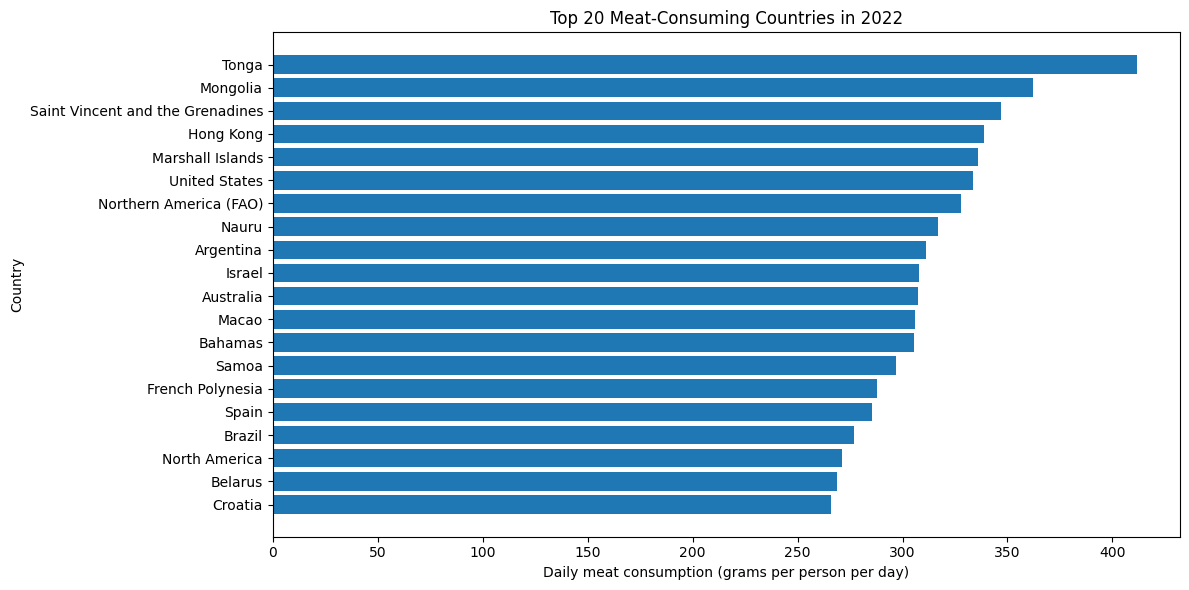

In [32]:
#Visualisation 
plt.figure(figsize=(12, 6))
plt.barh(top20[name_col], top20[meat_col])
plt.gca().invert_yaxis()   # highest at the top

plt.title("Top 20 Meat-Consuming Countries in 2022")
plt.xlabel("Daily meat consumption (grams per person per day)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

Conclusion

The 2022 meat consumption analysis reveals significant variation in dietary patterns across the world, with a relatively small group of countries exhibiting substantially higher per-capita intake compared to global averages. The top 20 consumers are predominantly economically developed nations, reflecting greater affordability, broader food availability, and cultural preferences that emphasize meat as a dietary staple. These findings highlight how socioeconomic factors, food systems, and cultural norms shape consumption behavior. Understanding these patterns is important not only for nutritional and public-health considerations but also for assessing environmental impacts, as higher meat consumption is closely linked to increased resource use and greenhouse gas emissions. Overall, the results provide valuable insight into global dietary trends and create a foundation for further research on sustainability, food security, and future consumption trajectories.